## Check GPU and CUDA

In [2]:
import sys
print(sys.version)

3.9.12 (tags/v3.9.12:b28265d, Mar 23 2022, 23:52:46) [MSC v.1929 64 bit (AMD64)]


In [3]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))

True
1
NVIDIA GeForce RTX 2060


# Load Enverotmed

In [ ]:
pip install pandas

In [18]:
!pip install av opencv-python-headless pafy yt-dlp

     ---------------------------------------- 0.0/183.8 kB ? eta -:--:--
     --------------- ----------------------- 71.7/183.8 kB 1.9 MB/s eta 0:00:01
     -------------------------------------- 183.8/183.8 kB 2.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/28.0 MB ? eta -:--:--
   - -------------------------------------- 0.7/28.0 MB 22.8 MB/s eta 0:00:02
   - -------------------------------------- 1.2/28.0 MB 15.1 MB/s eta 0:00:02
   -- ------------------------------------- 1.7/28.0 MB 15.1 MB/s eta 0:00:02
   --- ------------------------------------ 2.2/28.0 MB 15.3 MB/s eta 0:00:02
   --- ------------------------------------ 2.7/28.0 MB 14.2 MB/s eta 0:00:02
   ---- ----------------------------------- 3.3/28.0 MB 14.1 MB/s eta 0:00:02
   ----- ---------------------------------- 3.8/28.0 MB 14.3 MB/s eta 0:00:02
   ------ --------------------------------- 4.3/28.0 MB 13.8 MB/s eta 0:00:02
   ------ --------------------------------- 4.8/28.0 MB 13.8 MB/s eta 0:0


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\alexa\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [4]:
!pip install lapx

   ---------------------------------------- 0.0/226.8 kB ? eta -:--:--
   ---------- ----------------------------- 61.4/226.8 kB 3.2 MB/s eta 0:00:01
   ---------------------------------------- 226.8/226.8 kB 4.6 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\alexa\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [9]:
# ============================================================
# CELL FIX 2: Pastikan install ke Python yang dipakai notebook
# ============================================================
import sys
print("Python yang dipakai notebook:", sys.executable)
print("Versi:", sys.version)

# Install langsung ke Python yang aktif di notebook ini
!{sys.executable} -m pip install lapx

Python yang dipakai notebook: c:\Users\alexa\AppData\Local\Programs\Python\Python39\python.exe
Versi: 3.9.12 (tags/v3.9.12:b28265d, Mar 23 2022, 23:52:46) [MSC v.1929 64 bit (AMD64)]
     -------------------------------------- 226.9/226.9 KB 4.6 MB/s eta 0:00:00


You should consider upgrading via the 'c:\Users\alexa\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


# Load Dataset

In [11]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="EY2pDRbKs0yScLZ5S4ks")
project = rf.workspace("roboflow-100").project("vehicles-q0x2v")
version = project.version(2)
dataset = version.download("yolov12")
                


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\alexa\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


loading Roboflow workspace...
loading Roboflow project...


import YOLO form ultralytucs

In [12]:
from ultralytics import YOLO

# Preprosesing model 

In [6]:

# Load model
model = YOLO("yolo12n.pt")

# Training dengan hyperparameter yang bisa dituning
results = model.train(
    data="vehicles-2/data.yaml",

    # Training
    epochs=100,
    batch=8,
    imgsz=640,

    # Optimizer
    optimizer="adamw",
    lr0=0.001,
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0005,

    # Warmup
    warmup_epochs=3,
    warmup_momentum=0.8,
    warmup_bias_lr=0.1,

    # Augmentation
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    degrees=10,
    translate=0.1,
    scale=0.5,
    shear=2.0,
    perspective=0.0005,

    flipud=0.0,
    fliplr=0.5,

    mosaic=1.0,
    mixup=0.1,
    copy_paste=0.0,

    # Training options
    patience=20,
    workers=4,
    cache=False,
    device=0
)

New https://pypi.org/project/ultralytics/8.4.75 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.204  Python-3.9.12 torch-2.8.0+cu129 CUDA:0 (NVIDIA GeForce RTX 2060, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=vehicles-2/data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None

In [9]:
from ultralytics import YOLO

model = YOLO("runs/detect/train2/weights/best.pt")

results = model.predict(
    source="vehicles-2/test/images",
    conf=0.25,
    save=True
)


image 1/458 e:\Kerjaan\Car detection\vehicles-2\test\images\adit_mp4-1002_jpg.rf.5e4018e963af1251b3f7e6fd487c479e.jpg: 480x640 4 big trucks, 12 cars, 1 mid truck, 63.7ms
image 2/458 e:\Kerjaan\Car detection\vehicles-2\test\images\adit_mp4-1008_jpg.rf.e20ac34ac20c029e179d9c8bee45a078.jpg: 480x640 4 big trucks, 12 cars, 1 mid truck, 21.4ms
image 3/458 e:\Kerjaan\Car detection\vehicles-2\test\images\adit_mp4-1022_jpg.rf.8ec648b3f53103ded740458e94ae21f5.jpg: 480x640 2 big trucks, 11 cars, 27.8ms
image 4/458 e:\Kerjaan\Car detection\vehicles-2\test\images\adit_mp4-1028_jpg.rf.d9e26a9972e7a6815a2dff1bf35aca60.jpg: 480x640 1 big truck, 12 cars, 1 small truck, 19.5ms
image 5/458 e:\Kerjaan\Car detection\vehicles-2\test\images\adit_mp4-1035_jpg.rf.d42b43d55c46df6098b9bd71317b740d.jpg: 480x640 3 big trucks, 10 cars, 1 truck-l-, 19.7ms
image 6/458 e:\Kerjaan\Car detection\vehicles-2\test\images\adit_mp4-1049_jpg.rf.ddd000b665e067666e7ae5095494e47d.jpg: 480x640 4 big trucks, 9 cars, 1 small truck

#  Cek Hasil Prediksi pada Gambar Testing

Total gambar prediksi: 458


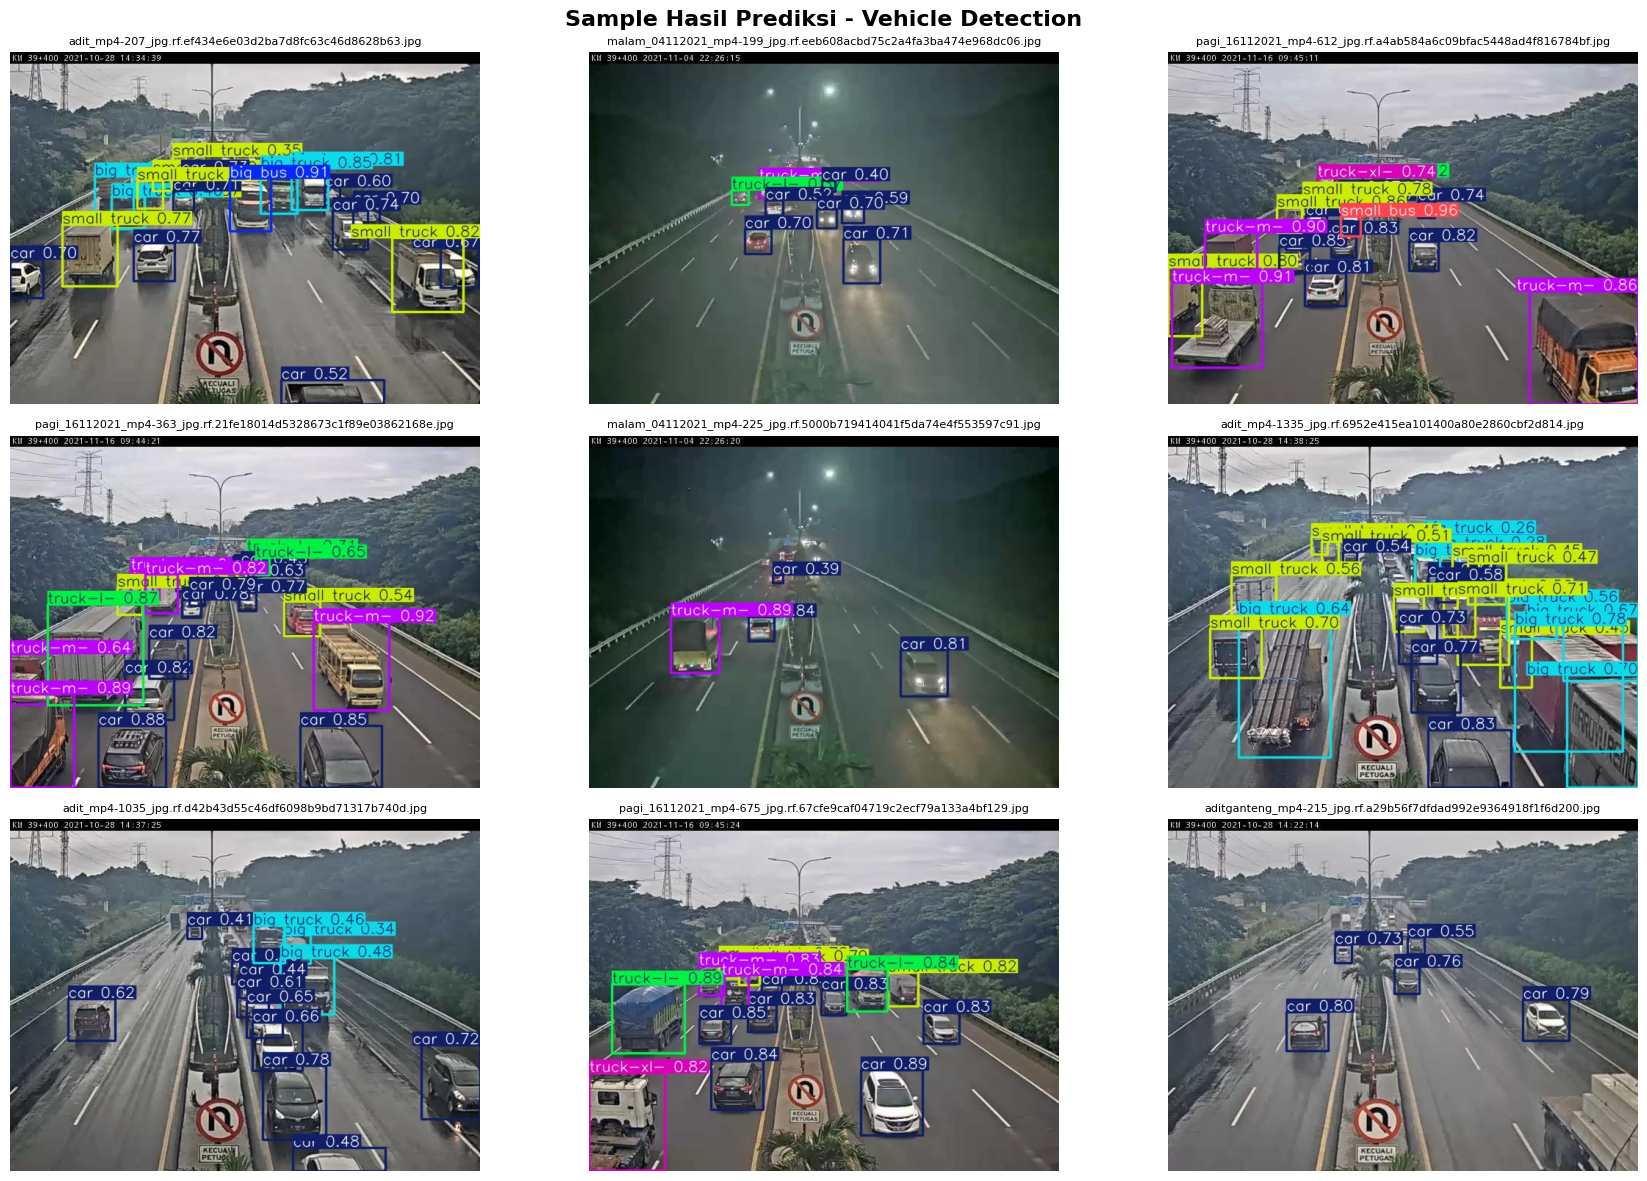

✅ Sample prediksi tersimpan: sample_predictions.png


In [ ]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

# Path ke hasil prediksi (sesuaikan dengan folder training kamu)
predict_dir = "runs/detect/predict"  # atau predict2, predict3, dst.

# Ambil semua gambar hasil prediksi
pred_images = list(Path(predict_dir).glob("*.jpg")) + \
              list(Path(predict_dir).glob("*.png"))

print(f"Total gambar prediksi: {len(pred_images)}")

# Tampilkan 9 gambar secara acak
sample = random.sample(pred_images, min(9, len(pred_images)))

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle("Sample Hasil Prediksi - Vehicle Detection", fontsize=16, fontweight='bold')

for ax, img_path in zip(axes.flatten(), sample):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.set_title(img_path.name, fontsize=8)
    ax.axis('off')

# Sembunyikan subplot kosong jika gambar < 9
for i in range(len(sample), 9):
    axes.flatten()[i].set_visible(False)

plt.tight_layout()
plt.savefig("sample_predictions.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sample prediksi tersimpan: sample_predictions.png")

# Visualisasi Grafik Nilai mAP dan Loss dari Training

Kolom yang tersedia: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']
   epoch      time  train/box_loss  train/cls_loss  train/dfl_loss  \
0      1   95.7842         1.57686         2.02404         1.21632   
1      2  178.9570         1.46866         1.50748         1.18410   
2      3  269.8680         1.44844         1.36944         1.18027   

   metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
0               0.32511            0.27880           0.15988   
1               0.48975            0.29795           0.25738   
2               0.42659            0.35313           0.27919   

   metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss    lr/pg0  \
0              0.07784       1.78915       1.48429       1.27293  0.067100   
1              0.15076       1.51477       1.28

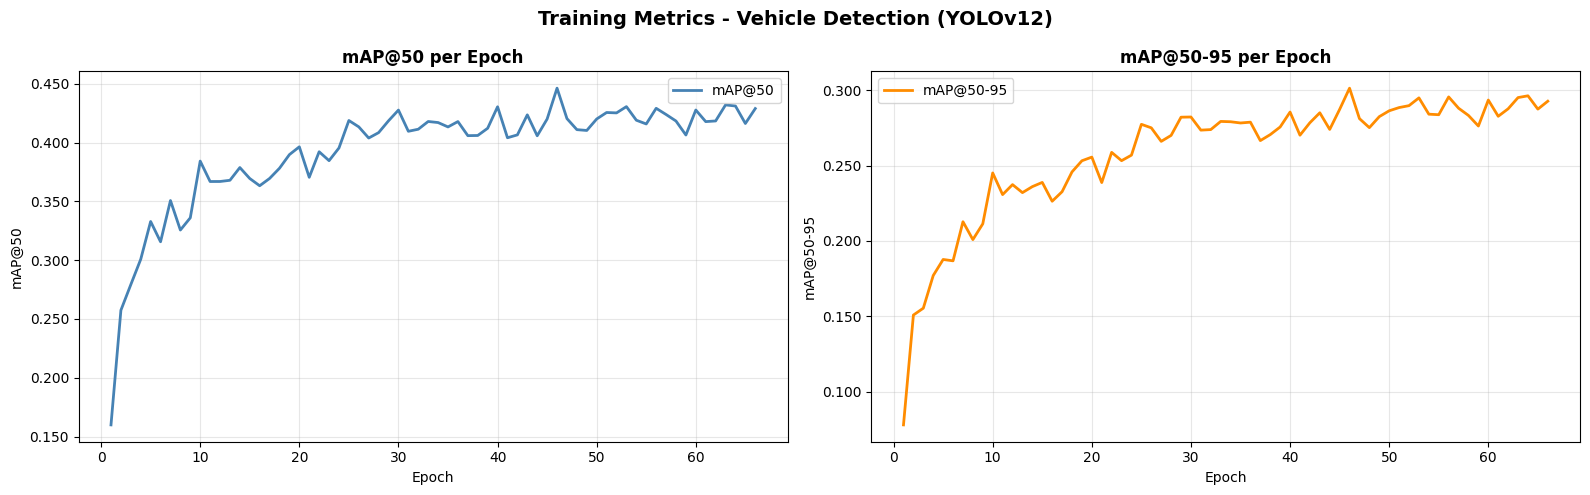

✅ Grafik mAP tersimpan: map_metrics.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Path ke file results.csv dari training
results_csv = "runs/detect/train2/results.csv"  # sesuaikan nama folder train kamu

df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()  # hapus whitespace pada nama kolom

print("Kolom yang tersedia:", df.columns.tolist())
print(df.head(3))

# ----------------------------------------------------------
# Plot 1: mAP50 dan mAP50-95
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Training Metrics - Vehicle Detection (YOLOv12)", fontsize=14, fontweight='bold')

# mAP50
axes[0].plot(df['epoch'], df['metrics/mAP50(B)'], color='steelblue', linewidth=2, label='mAP@50')
axes[0].set_title('mAP@50 per Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('mAP@50')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))

# mAP50-95
axes[1].plot(df['epoch'], df['metrics/mAP50-95(B)'], color='darkorange', linewidth=2, label='mAP@50-95')
axes[1].set_title('mAP@50-95 per Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('mAP@50-95')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))

plt.tight_layout()
plt.savefig("map_metrics.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik mAP tersimpan: map_metrics.png")

# Training Loss dan Validation Loss

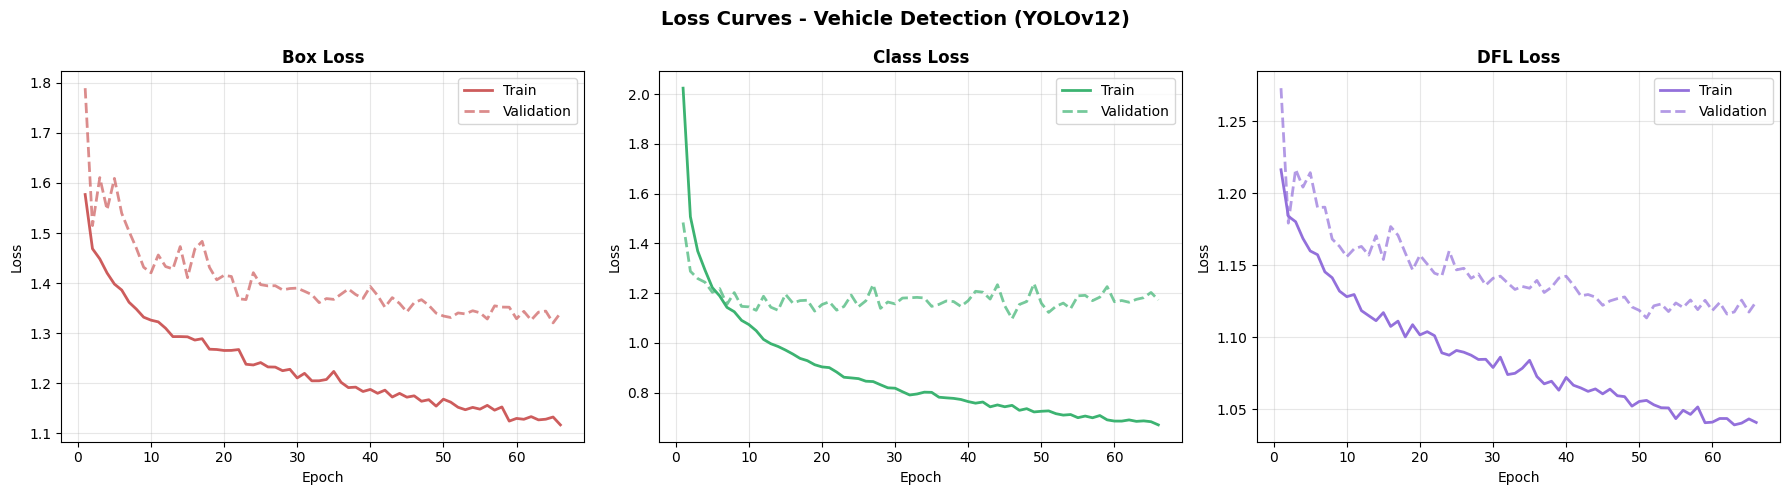

✅ Grafik loss tersimpan: loss_curves.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Loss Curves - Vehicle Detection (YOLOv12)", fontsize=14, fontweight='bold')

loss_pairs = [
    ('train/box_loss', 'val/box_loss', 'Box Loss', 'indianred'),
    ('train/cls_loss', 'val/cls_loss', 'Class Loss', 'mediumseagreen'),
    ('train/dfl_loss', 'val/dfl_loss', 'DFL Loss', 'mediumpurple'),
]

for ax, (train_col, val_col, title, color) in zip(axes, loss_pairs):
    ax.plot(df['epoch'], df[train_col], color=color, linewidth=2, label='Train')
    ax.plot(df['epoch'], df[val_col], color=color, linewidth=2, linestyle='--',
            alpha=0.7, label='Validation')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik loss tersimpan: loss_curves.png")

# Precision & Recall

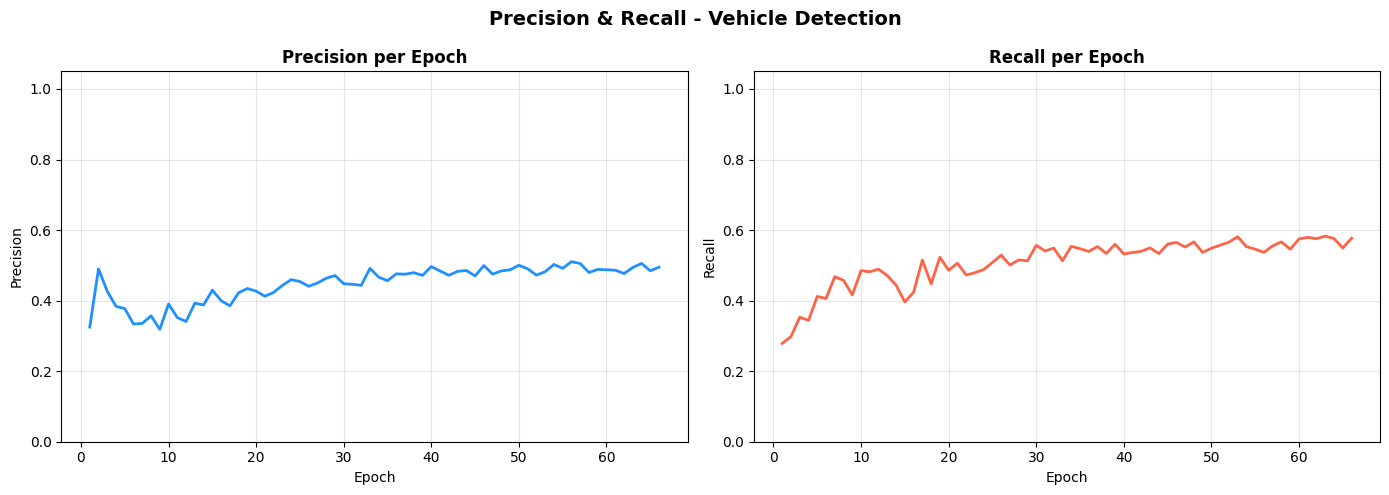

✅ Grafik precision & recall tersimpan: precision_recall.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Precision & Recall - Vehicle Detection", fontsize=14, fontweight='bold')

axes[0].plot(df['epoch'], df['metrics/precision(B)'], color='dodgerblue', linewidth=2)
axes[0].set_title('Precision per Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Precision')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1.05)

axes[1].plot(df['epoch'], df['metrics/recall(B)'], color='tomato', linewidth=2)
axes[1].set_title('Recall per Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Recall')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("precision_recall.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik precision & recall tersimpan: precision_recall.png")

# Confusion Matrix

In [ ]:
# Load best model
model = YOLO("runs/detect/train2/weights/best.pt")

# hasilkan confusion matrix otomatis
val_results = model.val(
    data="vehicles-2/data.yaml",
    split="test",        # pakai test set
    conf=0.25,
    iou=0.5,
    plots=True,          # ← ini yang generate confusion matrix
    save_json=True,
)

print("\n📊 Ringkasan Metrik Validasi:")
print(f"  mAP@50     : {val_results.box.map50:.4f}")
print(f"  mAP@50-95  : {val_results.box.map:.4f}")
print(f"  Precision  : {val_results.box.mp:.4f}")
print(f"  Recall     : {val_results.box.mr:.4f}")

Ultralytics 8.3.204  Python-3.9.12 torch-2.8.0+cu129 CUDA:0 (NVIDIA GeForce RTX 2060, 6144MiB)
YOLOv12n summary (fused): 159 layers, 2,559,068 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 480.7192.3 MB/s, size: 43.5 KB)
val: Scanning E:\Kerjaan\Car detection\vehicles-2\test\labels.cache... 458 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 458/458 346.4Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 4.3it/s 6.7s0.2s
                   all        458       6222      0.506       0.56       0.45      0.318
               big bus         82        110      0.816      0.482      0.663      0.481
             big truck        240        648       0.78      0.486      0.621      0.403
                bus-s-         15         16      0.418      0.562       0.44      0.354
                   car        445       4021      0.849      0.694      0.778      0.481
             m

# Menampilkan Confusion Matrix dari File yang Di-generate

📁 Folder validasi: runs\detect\val4


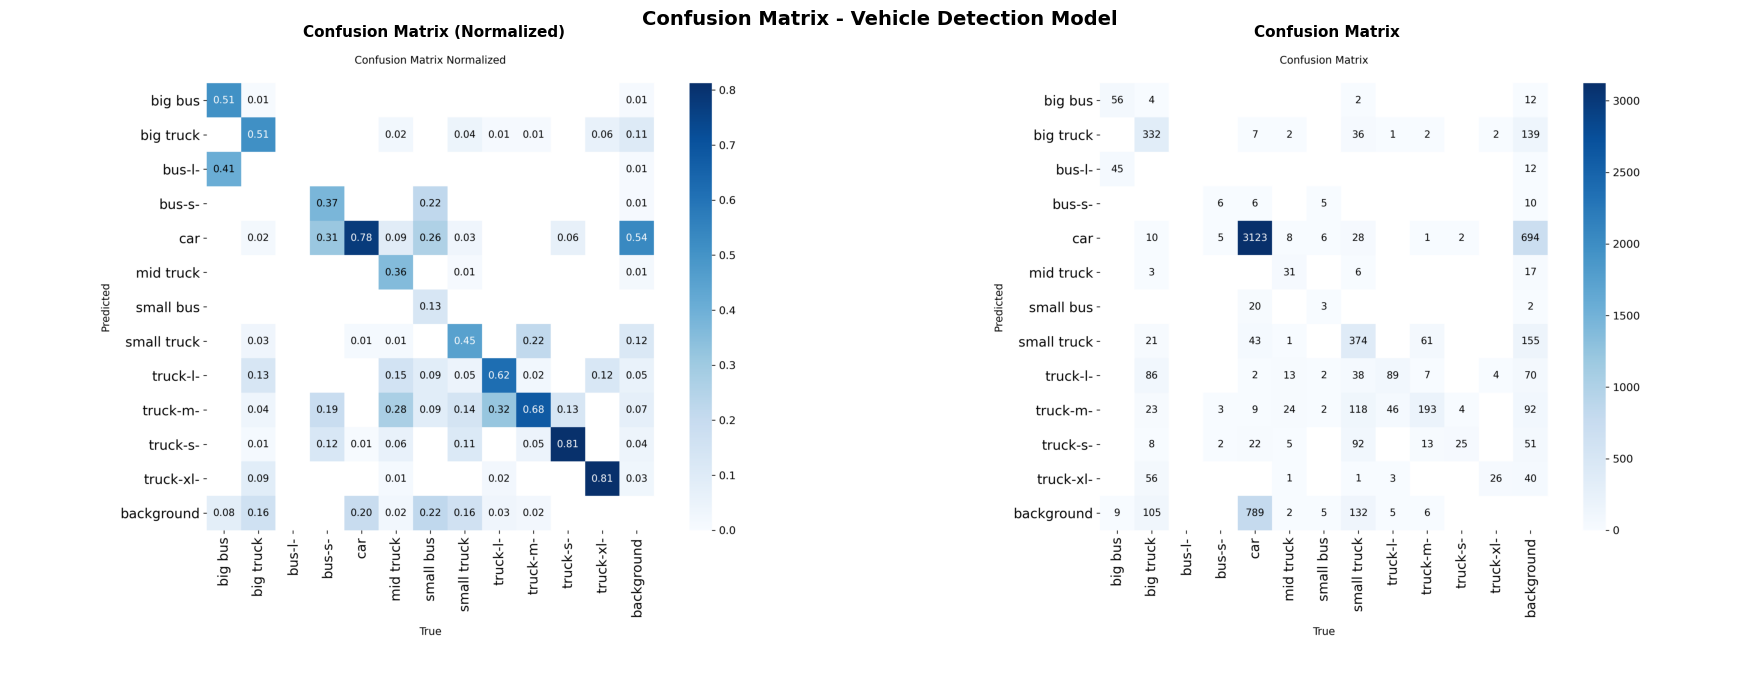

✅ Confusion matrix tersimpan: confusion_matrix_combined.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

# YOLO menyimpan confusion matrix di folder validasi
val_dir = sorted(Path("runs/detect").glob("val*"))[-1]  # ambil yang terbaru
print(f"📁 Folder validasi: {val_dir}")

# File confusion matrix yang di-generate YOLO
cm_files = {
    "Confusion Matrix (Normalized)": val_dir / "confusion_matrix_normalized.png",
    "Confusion Matrix": val_dir / "confusion_matrix.png",
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Confusion Matrix - Vehicle Detection Model", fontsize=14, fontweight='bold')

for ax, (title, cm_path) in zip(axes, cm_files.items()):
    if cm_path.exists():
        img = mpimg.imread(cm_path)
        ax.imshow(img)
        ax.set_title(title, fontweight='bold', fontsize=11)
        ax.axis('off')
    else:
        ax.text(0.5, 0.5, f"File tidak ditemukan:\n{cm_path.name}",
                ha='center', va='center', transform=ax.transAxes, color='red')
        ax.axis('off')

plt.tight_layout()
plt.savefig("confusion_matrix_combined.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix tersimpan: confusion_matrix_combined.png")

# Ringkasan Akhir Model

In [ ]:
print("=" * 55)
print("       RINGKASAN EVALUASI MODEL - VEHICLE DETECTION")
print("=" * 55)
print(f"  Model     : YOLOv12n (best.pt)")
print(f"  Dataset   : Vehicles (Roboflow-100)")
print(f"  mAP@50    : {val_results.box.map50:.4f}  ({val_results.box.map50*100:.2f}%)")
print(f"  mAP@50-95 : {val_results.box.map:.4f}  ({val_results.box.map*100:.2f}%)")
print(f"  Precision : {val_results.box.mp:.4f}  ({val_results.box.mp*100:.2f}%)")
print(f"  Recall    : {val_results.box.mr:.4f}  ({val_results.box.mr*100:.2f}%)")
print("=" * 55)

# Per-class AP
print("\n📌 AP per Kelas:")
names = model.names
for i, (ap50, ap) in enumerate(zip(val_results.box.ap50, val_results.box.ap)):
    print(f"  {names[i]:<20} AP@50: {ap50:.4f}  |  AP@50-95: {ap:.4f}")

       RINGKASAN EVALUASI MODEL - VEHICLE DETECTION
  Model     : YOLOv12n (best.pt)
  Dataset   : Vehicles (Roboflow-100)
  mAP@50    : 0.4495  (44.95%)
  mAP@50-95 : 0.3176  (31.76%)
  Precision : 0.5060  (50.60%)
  Recall    : 0.5601  (56.01%)

📌 AP per Kelas:
  big bus              AP@50: 0.6628  |  AP@50-95: 0.4808
  big truck            AP@50: 0.6208  |  AP@50-95: 0.4034
  bus-l-               AP@50: 0.4403  |  AP@50-95: 0.3539
  bus-s-               AP@50: 0.7785  |  AP@50-95: 0.4812
  car                  AP@50: 0.5717  |  AP@50-95: 0.4299
  mid truck            AP@50: 0.0939  |  AP@50-95: 0.0554
  small bus            AP@50: 0.5196  |  AP@50-95: 0.3426
  small truck          AP@50: 0.3315  |  AP@50-95: 0.2514
  truck-l-             AP@50: 0.4271  |  AP@50-95: 0.3239
  truck-m-             AP@50: 0.1781  |  AP@50-95: 0.1293
  truck-s-             AP@50: 0.3208  |  AP@50-95: 0.2417


# testing realtime menggunakan CCTV di Tol  (Realtime Vehicle Detection dari CCTV HLS Stream Tol Ciawi Selatan)

In [ ]:
import cv2
import time
import numpy as np
from ultralytics import YOLO
from collections import defaultdict
from IPython.display import display, Image, clear_output
import io

# Load model terbaik
model = YOLO("runs/detect/train2/weights/best.pt")

# URL stream HLS CCTV tol
HLS_URL = "https://www.tjt-info.co.id/LiveApp/streams/327294924686013390782781.m3u8"

# -------------------------------------------------------
# Konfigurasi
# -------------------------------------------------------
CONF_THRESHOLD = 0.70
DISPLAY_EVERY_N = 3        # tampilkan setiap N frame (hemat resource)
MAX_FRAMES = 300           # batas frame sebelum berhenti otomatis (opsional)
SAVE_OUTPUT = True         # simpan video hasil deteksi
OUTPUT_PATH = "output_cctv_detection.mp4"

# Warna per kelas (BGR)
COLORS = [
    (255, 100, 0), (0, 200, 255), (0, 255, 100),
    (255, 0, 200), (100, 0, 255), (255, 200, 0),
]

# -------------------------------------------------------
# Buka stream
# -------------------------------------------------------
print(f"🔗 Membuka stream: {HLS_URL}")
cap = cv2.VideoCapture(HLS_URL)

if not cap.isOpened():
    # Fallback: pakai ffmpeg backend
    cap = cv2.VideoCapture(HLS_URL, cv2.CAP_FFMPEG)

if not cap.isOpened():
    print("❌ Gagal membuka stream. Cek koneksi atau URL.")
else:
    print("✅ Stream berhasil dibuka!")
    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    print(f"   Resolusi: {w}x{h} @ {fps:.1f} FPS")

🔗 Membuka stream: https://www.tjt-info.co.id/LiveApp/streams/327294924686013390782781.m3u8
✅ Stream berhasil dibuka!
   Resolusi: 640x480 @ 25.0 FPS


# Jalankan Deteksi Class secara Realtime

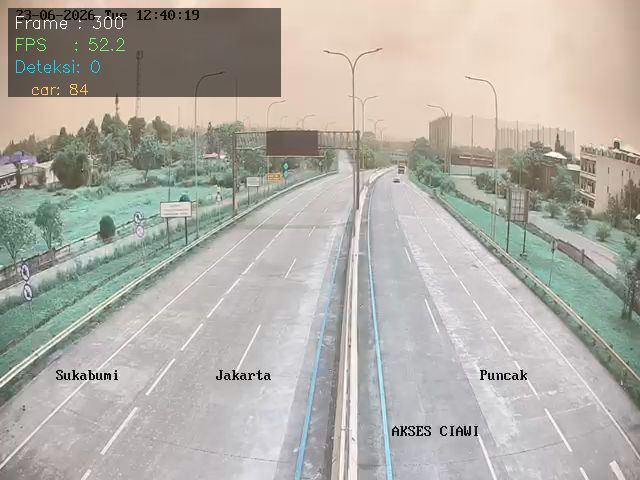

🎥 Frame 300 | FPS: 52.2
🚗 Kendaraan di frame ini : 0
📊 Akumulasi per kelas:
   car                 : 84

✅ Selesai: 300 frame diproses.

💾 Video disimpan: output_cctv_detection.mp4

       RINGKASAN AKHIR DETEKSI CCTV
  Total frame diproses : 300
  Rata-rata FPS        : 48.85

  Akumulasi Kendaraan per Kelas:
    car                 : 84

  TOTAL DETEKSI (semua kelas) : 84


In [2]:
model = YOLO("runs/detect/train2/weights/best.pt")
HLS_URL = "https://www.tjt-info.co.id/LiveApp/streams/327294924686013390782781.m3u8"

cap = cv2.VideoCapture(HLS_URL, cv2.CAP_FFMPEG)

# -------------------------------------------------------
# Video writer untuk menyimpan output
# -------------------------------------------------------
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out_writer = None

# -------------------------------------------------------
# Counting state
# -------------------------------------------------------
frame_count    = 0
total_detected = 0                # total deteksi per frame (running)
class_counter  = defaultdict(int) # akumulasi per kelas
fps_list       = []

print("🚗 Mulai deteksi kendaraan dari CCTV...")
print("   Tekan interrupt kernel untuk berhenti\n")

try:
    while cap.isOpened():
        t0 = time.time()
        ret, frame = cap.read()

        if not ret:
            print("⚠️  Frame tidak terbaca, mencoba reconnect...")
            time.sleep(2)
            cap = cv2.VideoCapture(HLS_URL, cv2.CAP_FFMPEG)
            continue

        frame_count += 1

        # -----------------------------------------------
        # Inferensi YOLO
        # -----------------------------------------------
        results = model.predict(
            source=frame,
            conf=CONF_THRESHOLD,
            verbose=False,
            stream=False
        )[0]

        # -----------------------------------------------
        # Parse deteksi
        # -----------------------------------------------
        detections = []
        if results.boxes is not None:
            for box in results.boxes:
                cls_id  = int(box.cls[0])
                conf    = float(box.conf[0])
                cls_name = model.names[cls_id]
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                detections.append((x1, y1, x2, y2, cls_name, conf, cls_id))
                class_counter[cls_name] += 1

        total_vehicles_this_frame = len(detections)

        # -----------------------------------------------
        # Gambar anotasi di frame
        # -----------------------------------------------
        annotated = frame.copy()
        h_f, w_f = annotated.shape[:2]

        for (x1, y1, x2, y2, cls_name, conf, cls_id) in detections:
            color = COLORS[cls_id % len(COLORS)]
            cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
            label = f"{cls_name} {conf:.2f}"
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)
            cv2.rectangle(annotated, (x1, y1 - th - 6), (x1 + tw + 4, y1), color, -1)
            cv2.putText(annotated, label, (x1 + 2, y1 - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1)

        # -----------------------------------------------
        # Overlay info panel
        # -----------------------------------------------
        elapsed_fps = 1.0 / (time.time() - t0 + 1e-6)
        fps_list.append(elapsed_fps)
        avg_fps = np.mean(fps_list[-30:])  # rolling 30 frame

        overlay = annotated.copy()
        panel_h = 30 + 22 * (len(class_counter) + 2)
        cv2.rectangle(overlay, (8, 8), (280, panel_h), (0, 0, 0), -1)
        cv2.addWeighted(overlay, 0.55, annotated, 0.45, 0, annotated)

        y_txt = 28
        cv2.putText(annotated, f"Frame : {frame_count}", (14, y_txt),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1); y_txt += 22
        cv2.putText(annotated, f"FPS   : {avg_fps:.1f}", (14, y_txt),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (100, 255, 100), 1); y_txt += 22
        cv2.putText(annotated, f"Deteksi: {total_vehicles_this_frame}", (14, y_txt),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 220, 255), 1); y_txt += 22

        for cls_name, count in class_counter.items():
            cv2.putText(annotated, f"  {cls_name}: {count}", (14, y_txt),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.50, (255, 200, 100), 1)
            y_txt += 22

        # -----------------------------------------------
        # Simpan ke video
        # -----------------------------------------------
        if SAVE_OUTPUT:
            if out_writer is None:
                out_writer = cv2.VideoWriter(
                    OUTPUT_PATH, fourcc, 20,
                    (annotated.shape[1], annotated.shape[0])
                )
            out_writer.write(annotated)

        # -----------------------------------------------
        # Tampilkan di notebook setiap N frame
        # -----------------------------------------------
        if frame_count % DISPLAY_EVERY_N == 0:
            rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
            _, buf = cv2.imencode(".jpg", rgb, [cv2.IMWRITE_JPEG_QUALITY, 80])
            clear_output(wait=True)
            display(Image(data=buf.tobytes()))

            # Print summary di bawah gambar
            print(f"🎥 Frame {frame_count} | FPS: {avg_fps:.1f}")
            print(f"🚗 Kendaraan di frame ini : {total_vehicles_this_frame}")
            print("📊 Akumulasi per kelas:")
            for k, v in class_counter.items():
                print(f"   {k:<20}: {v}")

        # Batas frame opsional
        if MAX_FRAMES and frame_count >= MAX_FRAMES:
            print(f"\n✅ Selesai: {MAX_FRAMES} frame diproses.")
            break

except KeyboardInterrupt:
    print("\n⛔ Dihentikan oleh user.")

finally:
    cap.release()
    if out_writer:
        out_writer.release()
        print(f"\n💾 Video disimpan: {OUTPUT_PATH}")

    print("\n" + "=" * 45)
    print("       RINGKASAN AKHIR DETEKSI CCTV")
    print("=" * 45)
    print(f"  Total frame diproses : {frame_count}")
    print(f"  Rata-rata FPS        : {np.mean(fps_list):.2f}")
    print(f"\n  Akumulasi Kendaraan per Kelas:")
    total_all = 0
    for k, v in class_counter.items():
        print(f"    {k:<20}: {v}")
        total_all += v
    print(f"\n  TOTAL DETEKSI (semua kelas) : {total_all}")
    print("=" * 45)

# Tracker and counting finall

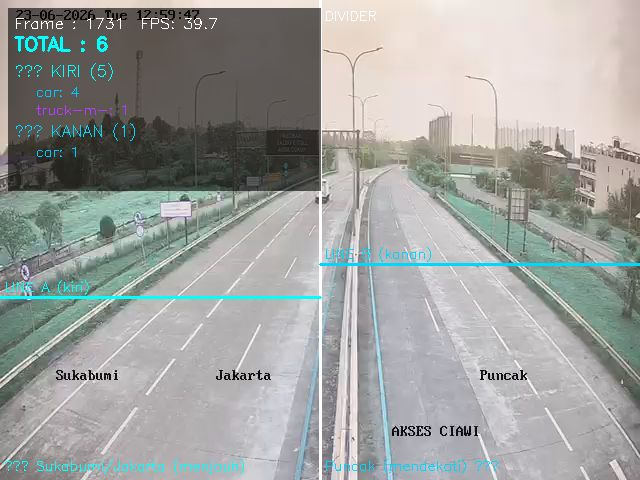

🎥 Frame 1731 | FPS 39.7
← Kiri  : 5  |  → Kanan : 1  |  TOTAL: 6

⛔ Dihentikan.
💾 Video: output_dual_lane.mp4

         HASIL COUNTING DUAL JALUR

  ← KIRI (Sukabumi/Jakarta)  — 5 kendaraan
    car                   :    4  (80.0%)
    truck-m-              :    1  (20.0%)

  → KANAN (Puncak/Ciawi)  — 1 kendaraan
    car                   :    1  (100.0%)

  GRAND TOTAL : 6 kendaraan


In [ ]:


model = YOLO("runs/detect/train2/weights/best.pt")
HLS_URL = "https://www.tjt-info.co.id/LiveApp/streams/327294924686013390782781.m3u8"

cap = cv2.VideoCapture(HLS_URL, cv2.CAP_FFMPEG)

# -------------------------------------------------------
# ⭐ Konfigurasi zona — sesuaikan dengan frame CCTV kamu
#
# Dari gambar CCTV:
#   - Pembatas jalan ada di sekitar x = 50% lebar frame
#   - Jalur KIRI  (Sukabumi/Jakarta): kendaraan MENJAUH
#     → bergerak dari bawah ke atas (cy mengecil)
#   - Jalur KANAN (Puncak): kendaraan MENDEKATI
#     → bergerak dari atas ke bawah (cy membesar)
# -------------------------------------------------------
CONF_THRESHOLD  = 0.70
IOU_THRESHOLD   = 0.45
DISPLAY_EVERY_N = 3
SAVE_OUTPUT     = True
OUTPUT_PATH     = "output_dual_lane.mp4"

# Pembatas jalan (x pixel) — 50% lebar frame
# Ubah jika posisi divider tidak tepat di tengah
DIVIDER_RATIO   = 0.55   # 50% dari lebar frame

# Posisi counting line per jalur (rasio dari tinggi frame)
LINE_LEFT_RATIO  = 0.62  # jalur kiri  — lebih ke bawah (kendaraan menjauh, bbox kecil)
LINE_RIGHT_RATIO = 0.55  # jalur kanan — lebih ke atas  (kendaraan mendekati, bbox besar)

# -------------------------------------------------------
# Tracking state
# -------------------------------------------------------
track_history  = defaultdict(list)  # {id: [(cx, cy_bottom, cy_top), ...]}
crossed_ids    = set()
cross_counter  = {
    "left"  : defaultdict(int),   # jalur kiri  (menjauh)
    "right" : defaultdict(int),   # jalur kanan (mendekati)
}
cross_log = []

COLORS = {
    'car'        : (0,   200, 255),
    'big bus'    : (255, 100,   0),
    'big truck'  : (100,   0, 255),
    'small truck': (0,   255, 100),
    'mid truck'  : (255, 200,   0),
    'small bus'  : (255,   0, 200),
    'truck-l-'   : (0,   100, 255),
    'truck-m-'   : (180,  60, 255),
    'truck-s-'   : (255,  60, 180),
    'truck-xl-'  : (60,  180, 255),
    'bus-l-'     : (255, 140,  60),
    'bus-s-'     : (60,  255, 140),
}
DEFAULT_COLOR = (200, 200, 200)

fourcc     = cv2.VideoWriter_fourcc(*'mp4v')
out_writer = None
frame_count = 0
fps_list    = []

print("🚗 Dual-Lane Counting aktif")
print(f"   Conf threshold : ≥ {int(CONF_THRESHOLD*100)}%")
print(f"   Divider        : {int(DIVIDER_RATIO*100)}% dari lebar frame")
print(f"   Line kiri      : {int(LINE_LEFT_RATIO*100)}% dari tinggi frame")
print(f"   Line kanan     : {int(LINE_RIGHT_RATIO*100)}% dari tinggi frame\n")

try:
    while cap.isOpened():
        t0  = time.time()
        ret, frame = cap.read()

        if not ret:
            print("⚠️  Reconnecting...")
            time.sleep(2)
            cap = cv2.VideoCapture(HLS_URL, cv2.CAP_FFMPEG)
            continue

        frame_count += 1
        h_f, w_f    = frame.shape[:2]

        # Hitung pixel dari rasio
        X_DIVIDER    = int(w_f * DIVIDER_RATIO)
        Y_LINE_LEFT  = int(h_f * LINE_LEFT_RATIO)
        Y_LINE_RIGHT = int(h_f * LINE_RIGHT_RATIO)

        # -----------------------------------------------
        # Inferensi + ByteTrack
        # -----------------------------------------------
        results = model.track(
            source=frame,
            conf=CONF_THRESHOLD,
            iou=IOU_THRESHOLD,
            tracker="bytetrack.yaml",
            persist=True,
            verbose=False,
        )[0]

        annotated = frame.copy()

        # -----------------------------------------------
        # Gambar pembatas & garis counting
        # -----------------------------------------------
        # Divider (garis putih vertikal)
        cv2.line(annotated, (X_DIVIDER, 0), (X_DIVIDER, h_f),
                 (255, 255, 255), 2)
        cv2.putText(annotated, "DIVIDER", (X_DIVIDER + 4, 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1)

        # Counting line kiri (cyan)
        cv2.line(annotated, (0, Y_LINE_LEFT), (X_DIVIDER, Y_LINE_LEFT),
                 (0, 255, 255), 2)
        cv2.putText(annotated, "LINE A (kiri)", (4, Y_LINE_LEFT - 6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 255, 255), 1)

        # Counting line kanan (kuning)
        cv2.line(annotated, (X_DIVIDER, Y_LINE_RIGHT), (w_f, Y_LINE_RIGHT),
                 (0, 215, 255), 2)
        cv2.putText(annotated, "LINE B (kanan)", (X_DIVIDER + 4, Y_LINE_RIGHT - 6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 215, 255), 1)

        # Label arah jalur
        cv2.putText(annotated, "← Sukabumi/Jakarta (menjauh)",
                    (4, h_f - 10), cv2.FONT_HERSHEY_SIMPLEX,
                    0.45, (0, 255, 255), 1)
        cv2.putText(annotated, "Puncak (mendekati) →",
                    (X_DIVIDER + 4, h_f - 10), cv2.FONT_HERSHEY_SIMPLEX,
                    0.45, (0, 215, 255), 1)

        # -----------------------------------------------
        # Proses deteksi
        # -----------------------------------------------
        newly_crossed = []

        if results.boxes is not None and results.boxes.id is not None:
            for box in results.boxes:
                track_id = int(box.id[0])
                cls_id   = int(box.cls[0])
                conf     = float(box.conf[0])
                cls_name = model.names[cls_id]
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                cx        = (x1 + x2) // 2
                cy_bottom = y2
                cy_top    = y1

                color = COLORS.get(cls_name, DEFAULT_COLOR)

                # Tentukan jalur berdasarkan posisi cx
                lane = "left" if cx < X_DIVIDER else "right"

                # Simpan history: (cx, cy_bottom, cy_top)
                track_history[track_id].append((cx, cy_bottom, cy_top))
                if len(track_history[track_id]) > 30:
                    track_history[track_id].pop(0)

                history = track_history[track_id]

                if len(history) >= 2 and track_id not in crossed_ids:
                    prev = history[-2]
                    curr = history[-1]

                    crossed = False

                    if lane == "left":
                        # Jalur kiri: kendaraan MENJAUH → bergerak ke ATAS
                        # cy_bottom turun dari besar → kecil
                        # Crossing: cy_bottom melewati LINE_LEFT dari bawah ke atas
                        if prev[1] >= Y_LINE_LEFT and curr[1] < Y_LINE_LEFT:
                            crossed = True

                    else:
                        # Jalur kanan: kendaraan MENDEKATI → bergerak ke BAWAH
                        # cy_bottom naik dari kecil → besar
                        # Crossing: cy_bottom melewati LINE_RIGHT dari atas ke bawah
                        if prev[1] < Y_LINE_RIGHT and curr[1] >= Y_LINE_RIGHT:
                            crossed = True

                    if crossed:
                        crossed_ids.add(track_id)
                        cross_counter[lane][cls_name] += 1
                        newly_crossed.append((cls_name, conf, cx,
                            Y_LINE_LEFT if lane == "left" else Y_LINE_RIGHT,
                            lane, color))
                        cross_log.append({
                            "frame"   : frame_count,
                            "lane"    : lane,
                            "class"   : cls_name,
                            "conf"    : round(conf, 3),
                            "track_id": track_id,
                        })
                        lane_label = "KIRI ←" if lane == "left" else "KANAN →"
                        print(f"  ✅ Frame {frame_count} | {lane_label} | "
                              f"+1 {cls_name} ({conf:.0%}, ID:{track_id})")

                # Gambar bounding box
                cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)

                # Label
                lane_icon = "←" if lane == "left" else "→"
                label = f"{lane_icon}#{track_id} {cls_name} {conf:.0%}"
                (tw, th), _ = cv2.getTextSize(
                    label, cv2.FONT_HERSHEY_SIMPLEX, 0.48, 1)
                cv2.rectangle(annotated,
                              (x1, y1-th-6), (x1+tw+4, y1), color, -1)
                cv2.putText(annotated, label, (x1+2, y1-4),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.48,
                            (255, 255, 255), 1)

                # Trail jejak
                if len(history) > 1:
                    for i in range(1, min(len(history), 12)):
                        cv2.line(annotated,
                                 (history[-(i+1)][0], history[-(i+1)][1]),
                                 (history[-i][0],     history[-i][1]),
                                 tuple(int(c * (i/12)) for c in color), 1)

        # -----------------------------------------------
        # Flash efek saat crossing
        # -----------------------------------------------
        for (cls_n, conf_c, cx_c, cy_c, lane_c, col_c) in newly_crossed:
            cv2.circle(annotated, (cx_c, cy_c), 22, col_c, -1)
            cv2.circle(annotated, (cx_c, cy_c), 28, (255, 255, 255), 2)
            arah = "←" if lane_c == "left" else "→"
            cv2.putText(annotated, f"{arah}+1 {cls_n}",
                        (cx_c + 32, cy_c + 8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.75, col_c, 2)

        # -----------------------------------------------
        # Panel info
        # -----------------------------------------------
        elapsed_fps = 1.0 / (time.time() - t0 + 1e-6)
        fps_list.append(elapsed_fps)
        avg_fps = np.mean(fps_list[-30:])

        total_left  = sum(cross_counter["left"].values())
        total_right = sum(cross_counter["right"].values())
        total_all   = total_left + total_right

        n_lines   = 5 + len(cross_counter["left"]) + len(cross_counter["right"])
        panel_h   = 14 + 22 * n_lines

        overlay = annotated.copy()
        cv2.rectangle(overlay, (8, 8), (320, panel_h), (0, 0, 0), -1)
        cv2.addWeighted(overlay, 0.6, annotated, 0.4, 0, annotated)

        y = 28
        cv2.putText(annotated, f"Frame : {frame_count}  FPS: {avg_fps:.1f}",
                    (14, y), cv2.FONT_HERSHEY_SIMPLEX, 0.50,
                    (255, 255, 255), 1); y += 22
        cv2.putText(annotated, f"TOTAL : {total_all}",
                    (14, y), cv2.FONT_HERSHEY_SIMPLEX, 0.62,
                    (0, 255, 255), 2); y += 26

        # Panel kiri
        cv2.putText(annotated, f"← KIRI ({total_left})",
                    (14, y), cv2.FONT_HERSHEY_SIMPLEX, 0.52,
                    (0, 255, 255), 1); y += 20
        for k, v in sorted(cross_counter["left"].items(), key=lambda x: -x[1]):
            cv2.putText(annotated, f"   {k}: {v}", (14, y),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45,
                        COLORS.get(k, DEFAULT_COLOR), 1); y += 18

        y += 4
        # Panel kanan
        cv2.putText(annotated, f"→ KANAN ({total_right})",
                    (14, y), cv2.FONT_HERSHEY_SIMPLEX, 0.52,
                    (0, 215, 255), 1); y += 20
        for k, v in sorted(cross_counter["right"].items(), key=lambda x: -x[1]):
            cv2.putText(annotated, f"   {k}: {v}", (14, y),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45,
                        COLORS.get(k, DEFAULT_COLOR), 1); y += 18

        # -----------------------------------------------
        # Simpan & display
        # -----------------------------------------------
        if SAVE_OUTPUT:
            if out_writer is None:
                out_writer = cv2.VideoWriter(
                    OUTPUT_PATH, fourcc, 20,
                    (annotated.shape[1], annotated.shape[0])
                )
            out_writer.write(annotated)

        if frame_count % DISPLAY_EVERY_N == 0:
            rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
            _, buf = cv2.imencode(".jpg", rgb,
                                  [cv2.IMWRITE_JPEG_QUALITY, 80])
            clear_output(wait=True)
            display(Image(data=buf.tobytes()))
            print(f"🎥 Frame {frame_count} | FPS {avg_fps:.1f}")
            print(f"← Kiri  : {total_left}  |  → Kanan : {total_right}  "
                  f"|  TOTAL: {total_all}")

except KeyboardInterrupt:
    print("\n⛔ Dihentikan.")

finally:
    cap.release()
    if out_writer:
        out_writer.release()
        print(f"💾 Video: {OUTPUT_PATH}")

    print("\n" + "=" * 55)
    print("         HASIL COUNTING DUAL JALUR")
    print("=" * 55)
    for lane_key, lane_label in [("left","← KIRI (Sukabumi/Jakarta)"),
                                  ("right","→ KANAN (Puncak/Ciawi)")]:
        total = sum(cross_counter[lane_key].values())
        print(f"\n  {lane_label}  — {total} kendaraan")
        for k, v in sorted(cross_counter[lane_key].items(), key=lambda x:-x[1]):
            pct = v/total*100 if total else 0
            print(f"    {k:<22}: {v:>4}  ({pct:.1f}%)")
    grand = sum(cross_counter["left"].values()) + \
            sum(cross_counter["right"].values())
    print(f"\n  GRAND TOTAL : {grand} kendaraan")
    print("=" * 55)